###Backpropogation Algorithm
######Step 1: Forward Pass
######Step 2: Loss Calculation
######Step 3: Backward Pass
######Step 4: Parameter Update

Import the required libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Define various functions that will be needed to implement algorithm

In [ ]:
def log_seg(z):
  y_pred = 1/(1+np.exp(-z))
  return y_pred

def mse_loss(y_pred, y):
  loss = 0.5*np.mean((y_pred-y)**2)
  return loss

def der_mse_loss(y_pred, y):
  N = y.shape[0]
  return (y_pred-y)/N

def der_log_seg(y_pred, y):
  return y_pred*(1-y_pred)

def w_update(w, l_rt, grad):
  w_new = w - l_rt*grad
  return w_new

Import the dataset needed for training

In [ ]:
x = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([[0],
              [0],
              [0],
              [1]])
print(x)
print(x.shape[0])
print(y)
print(y.shape[0])

[[0 0]
 [0 1]
 [1 0]
 [1 1]]
4
[[0]
 [0]
 [0]
 [1]]
4


Initializing the parameters and hyperparameters

In [ ]:
w = np.random.randn(2,1)
print(w)
b = np.random.randn()
print(b)

# Hyperparameters
l_rt = 0.2
n_it = 25000
loss_val = []

[[0.05497772]
 [0.28994928]]
0.1524068137589604


Implementing the training

In [ ]:
# x->(4x2) w->(2x1) b->(1x1)
# z is Vector of dimension 4x1
for k in range(n_it):
  # Step 1: Forward pass
  z = np.dot(x, w) + b # np.dot is for matrix multiplication
  y_pred = log_seg(z)

  # Step 2: Loss Calculation
  loss = mse_loss(y_pred, y)
  loss_val.append(loss)

  # Step 3: Backward Pass
  # dLoss/dw1 = (dLoss/dy') * (dy'/dz) * (dz/dw1) = grad_1 * grad_2 * grad_3 (for bias grad_3 will be  1 and for weights it will be input)
  grad_1 = der_mse_loss(y_pred, y) #(4x1)
  grad_2 = der_log_seg(y_pred, y) #(4x1)
  grad = grad_1*grad_2 #(4x1)
  #x->(4,2) take xT->(2,4) grad->(4x1) grad_w = xT.grad
  grad_w = np.dot(x.T, grad) #(2x1)
  grad_b = np.sum(grad) #(1x1)

  w = w_update(w, l_rt, grad_w)
  b = w_update(b, l_rt, grad_b)

print('y_pred = ',np.round(y_pred,3))
print('y = ',np.round(y,3))

y_pred =  [[0.   ]
 [0.049]
 [0.049]
 [0.941]]
y =  [[0]
 [0]
 [0]
 [1]]


Visualizing the results

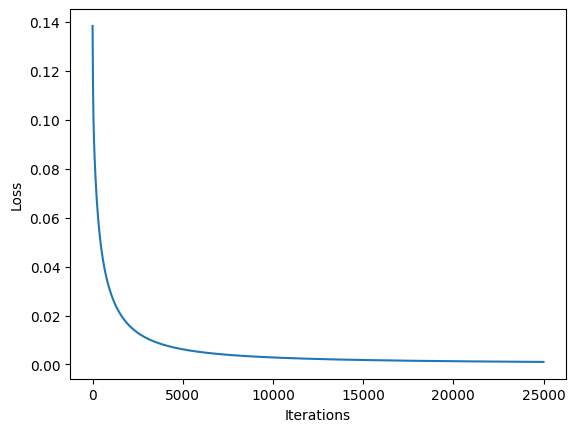

In [ ]:
plt.plot(loss_val)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()

[[0 0]
 [0 1]
 [1 0]
 [1 1]]
4
[[0]
 [1]
 [1]
 [1]]
4
[[-0.62250974]
 [ 0.61403559]]
-0.5817875861274028
y_pred =  [[0.049]
 [0.97 ]
 [0.97 ]
 [1.   ]]
y_OR =  [[0]
 [1]
 [1]
 [1]]


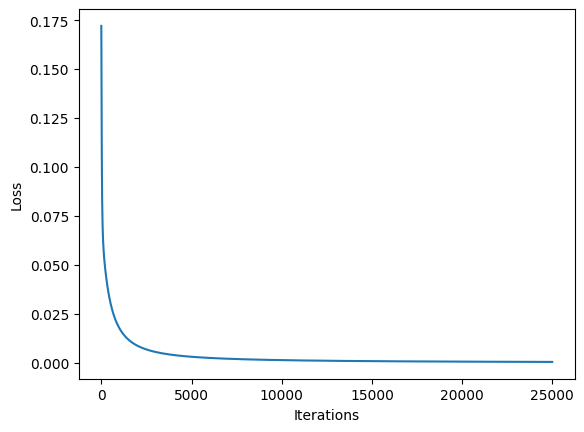

In [ ]:
x_OR = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y_OR = np.array([[0],
              [1],
              [1],
              [1]])
print(x_OR)
print(x_OR.shape[0])
print(y_OR)
print(y_OR.shape[0])

w = np.random.randn(2,1)
print(w)
b = np.random.randn()
print(b)

# Hyperparameters
l_rt = 0.2
n_it = 25000
loss_val = []

# x->(4x2) w->(2x1) b->(1x1)
# z is Vector of dimension 4x1
for k in range(n_it):
  # Step 1: Forward pass
  z = np.dot(x_OR, w) + b # np.dot is for matrix multiplication
  y_pred = log_seg(z)

  # Step 2: Loss Calculation
  loss = mse_loss(y_pred, y_OR)
  loss_val.append(loss)

  # Step 3: Backward Pass
  # dLoss/dw1 = (dLoss/dy') * (dy'/dz) * (dz/dw1) = grad_1 * grad_2 * grad_3 (for bias grad_3 will be  1 and for weights it will be input)
  grad_1 = der_mse_loss(y_pred, y_OR) #(4x1)
  grad_2 = der_log_seg(y_pred, y_OR) #(4x1)
  grad = grad_1*grad_2 #(4x1)
  #x->(4,2) take xT->(2,4) grad->(4x1) grad_w = xT.grad
  grad_w = np.dot(x_OR.T, grad) #(2x1)
  grad_b = np.sum(grad) #(1x1)

  w = w_update(w, l_rt, grad_w)
  b = w_update(b, l_rt, grad_b)

print('y_pred = ',np.round(y_pred,3))
print('y_OR = ',np.round(y_OR,3))

plt.plot(loss_val)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()